# Data Analysis Project

## I. Understanding & Preparing the Dataset

### Uploading the dataset

In [129]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
X = df.iloc[:, [3, 4]].values

df.head()


Saving archive (11).zip to archive (11) (1).zip


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


### Droping unecessary columns


In [130]:
df = df.drop(columns=['Sl. No', 'Patient File No.','Unnamed: 44'])
df.head()


,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,0,28,44.6,152.0,19.3,15,78,22,10.48,2,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,0,36,65.0,161.5,24.9,15,74,20,11.70,2,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,1,33,68.8,165.0,25.3,11,72,18,11.80,2,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,0,37,65.0,148.0,29.7,13,72,20,12.00,2,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,0,25,52.0,161.0,20.1,11,72,18,10.00,2,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


## II. Handling Missing Values


### Computing the percentage of missing values

In [131]:
missing_percent = (df.isna().sum() / len(df)) * 100

missing_df = missing_percent.reset_index()
missing_df.columns = ['Column', 'Missing_Percentage']

missing_df


,Column,Missing_Percentage
0,PCOS (Y/N),0.000000
1,Age (yrs),0.000000
2,Weight (Kg),0.000000
3,Height(Cm),0.000000
4,BMI,0.000000
5,Blood Group,0.000000
6,Pulse rate(bpm),0.000000
7,RR (breaths/min),0.000000
8,Hb(g/dl),0.000000
9,Cycle(R/I),0.000000


We only have 3 columns with missing value with a percentage of 0.184 , checking the source of the dataset I found that only one value is missing per column so we can drop those columns safely

In [132]:
df = df.dropna(subset=['Marraige Status (Yrs)', 'Fast food (Y/N)','AMH(ng/mL)'])



### Cleaning the Data

In [133]:
import numpy as np

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = (
            df[col]
            .str.replace(r'[^0-9.-]', '', regex=True)
            .replace('', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='ignore')


/tmp/ipython-input-1245884928.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


## III. Encoding Categorical Variables

In [134]:
df['PCOS (Y/N)'].value_counts(dropna=False)


,count
PCOS (Y/N),
0,363
1,176


In [135]:
yn_columns = [
    'PCOS (Y/N)', 'Pregnant(Y/N)', 'Weight gain(Y/N)',
    'hair growth(Y/N)', 'Skin darkening (Y/N)',
    'Hair loss(Y/N)', 'Pimples(Y/N)',
    'Fast food (Y/N)', 'Reg.Exercise(Y/N)'
]

for col in yn_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')





## IV. Detecting & Treating Outliers

In [136]:
df.columns.tolist()




['PCOS (Y/N)',
 ' Age (yrs)',
 'Weight (Kg)',
 'Height(Cm) ',
 'BMI',
 'Blood Group',
 'Pulse rate(bpm) ',
 'RR (breaths/min)',
 'Hb(g/dl)',
 'Cycle(R/I)',
 'Cycle length(days)',
 'Marraige Status (Yrs)',
 'Pregnant(Y/N)',
 'No. of abortions',
 '  I   beta-HCG(mIU/mL)',
 'II    beta-HCG(mIU/mL)',
 'FSH(mIU/mL)',
 'LH(mIU/mL)',
 'FSH/LH',
 'Hip(inch)',
 'Waist(inch)',
 'Waist:Hip Ratio',
 'TSH (mIU/L)',
 'AMH(ng/mL)',
 'PRL(ng/mL)',
 'Vit D3 (ng/mL)',
 'PRG(ng/mL)',
 'RBS(mg/dl)',
 'Weight gain(Y/N)',
 'hair growth(Y/N)',
 'Skin darkening (Y/N)',
 'Hair loss(Y/N)',
 'Pimples(Y/N)',
 'Fast food (Y/N)',
 'Reg.Exercise(Y/N)',
 'BP _Systolic (mmHg)',
 'BP _Diastolic (mmHg)',
 'Follicle No. (L)',
 'Follicle No. (R)',
 'Avg. F size (L) (mm)',
 'Avg. F size (R) (mm)',
 'Endometrium (mm)']

In [137]:
# Select only continuous numerical columns
continuous_cols = [
    ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI',
    'Pulse rate(bpm) ', 'RR (breaths/min)',
    'Hb(g/dl)', 'FSH(mIU/mL)', 'LH(mIU/mL)',
    'FSH/LH', 'TSH (mIU/L)', 'AMH(ng/mL)',
    'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)',
    'RBS(mg/dl)', 'Hip(inch)', 'Waist(inch)',
    'Waist:Hip Ratio', 'BP _Systolic (mmHg)',
    'BP _Diastolic (mmHg)', 'Endometrium (mm)'
]


outlier_results = []

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_results.append([col, count])

outliers_df = pd.DataFrame(
    outlier_results,
    columns=['Column', 'Outlier_Count']
).sort_values(by='Outlier_Count', ascending=False)

outliers_df


,Column,Outlier_Count
4,Pulse rate(bpm),94
11,AMH(ng/mL),52
9,FSH/LH,49
14,PRG(ng/mL),38
13,Vit D3 (ng/mL),30
15,RBS(mg/dl),30
10,TSH (mIU/L),27
8,LH(mIU/mL),24
16,Hip(inch),21
12,PRL(ng/mL),21


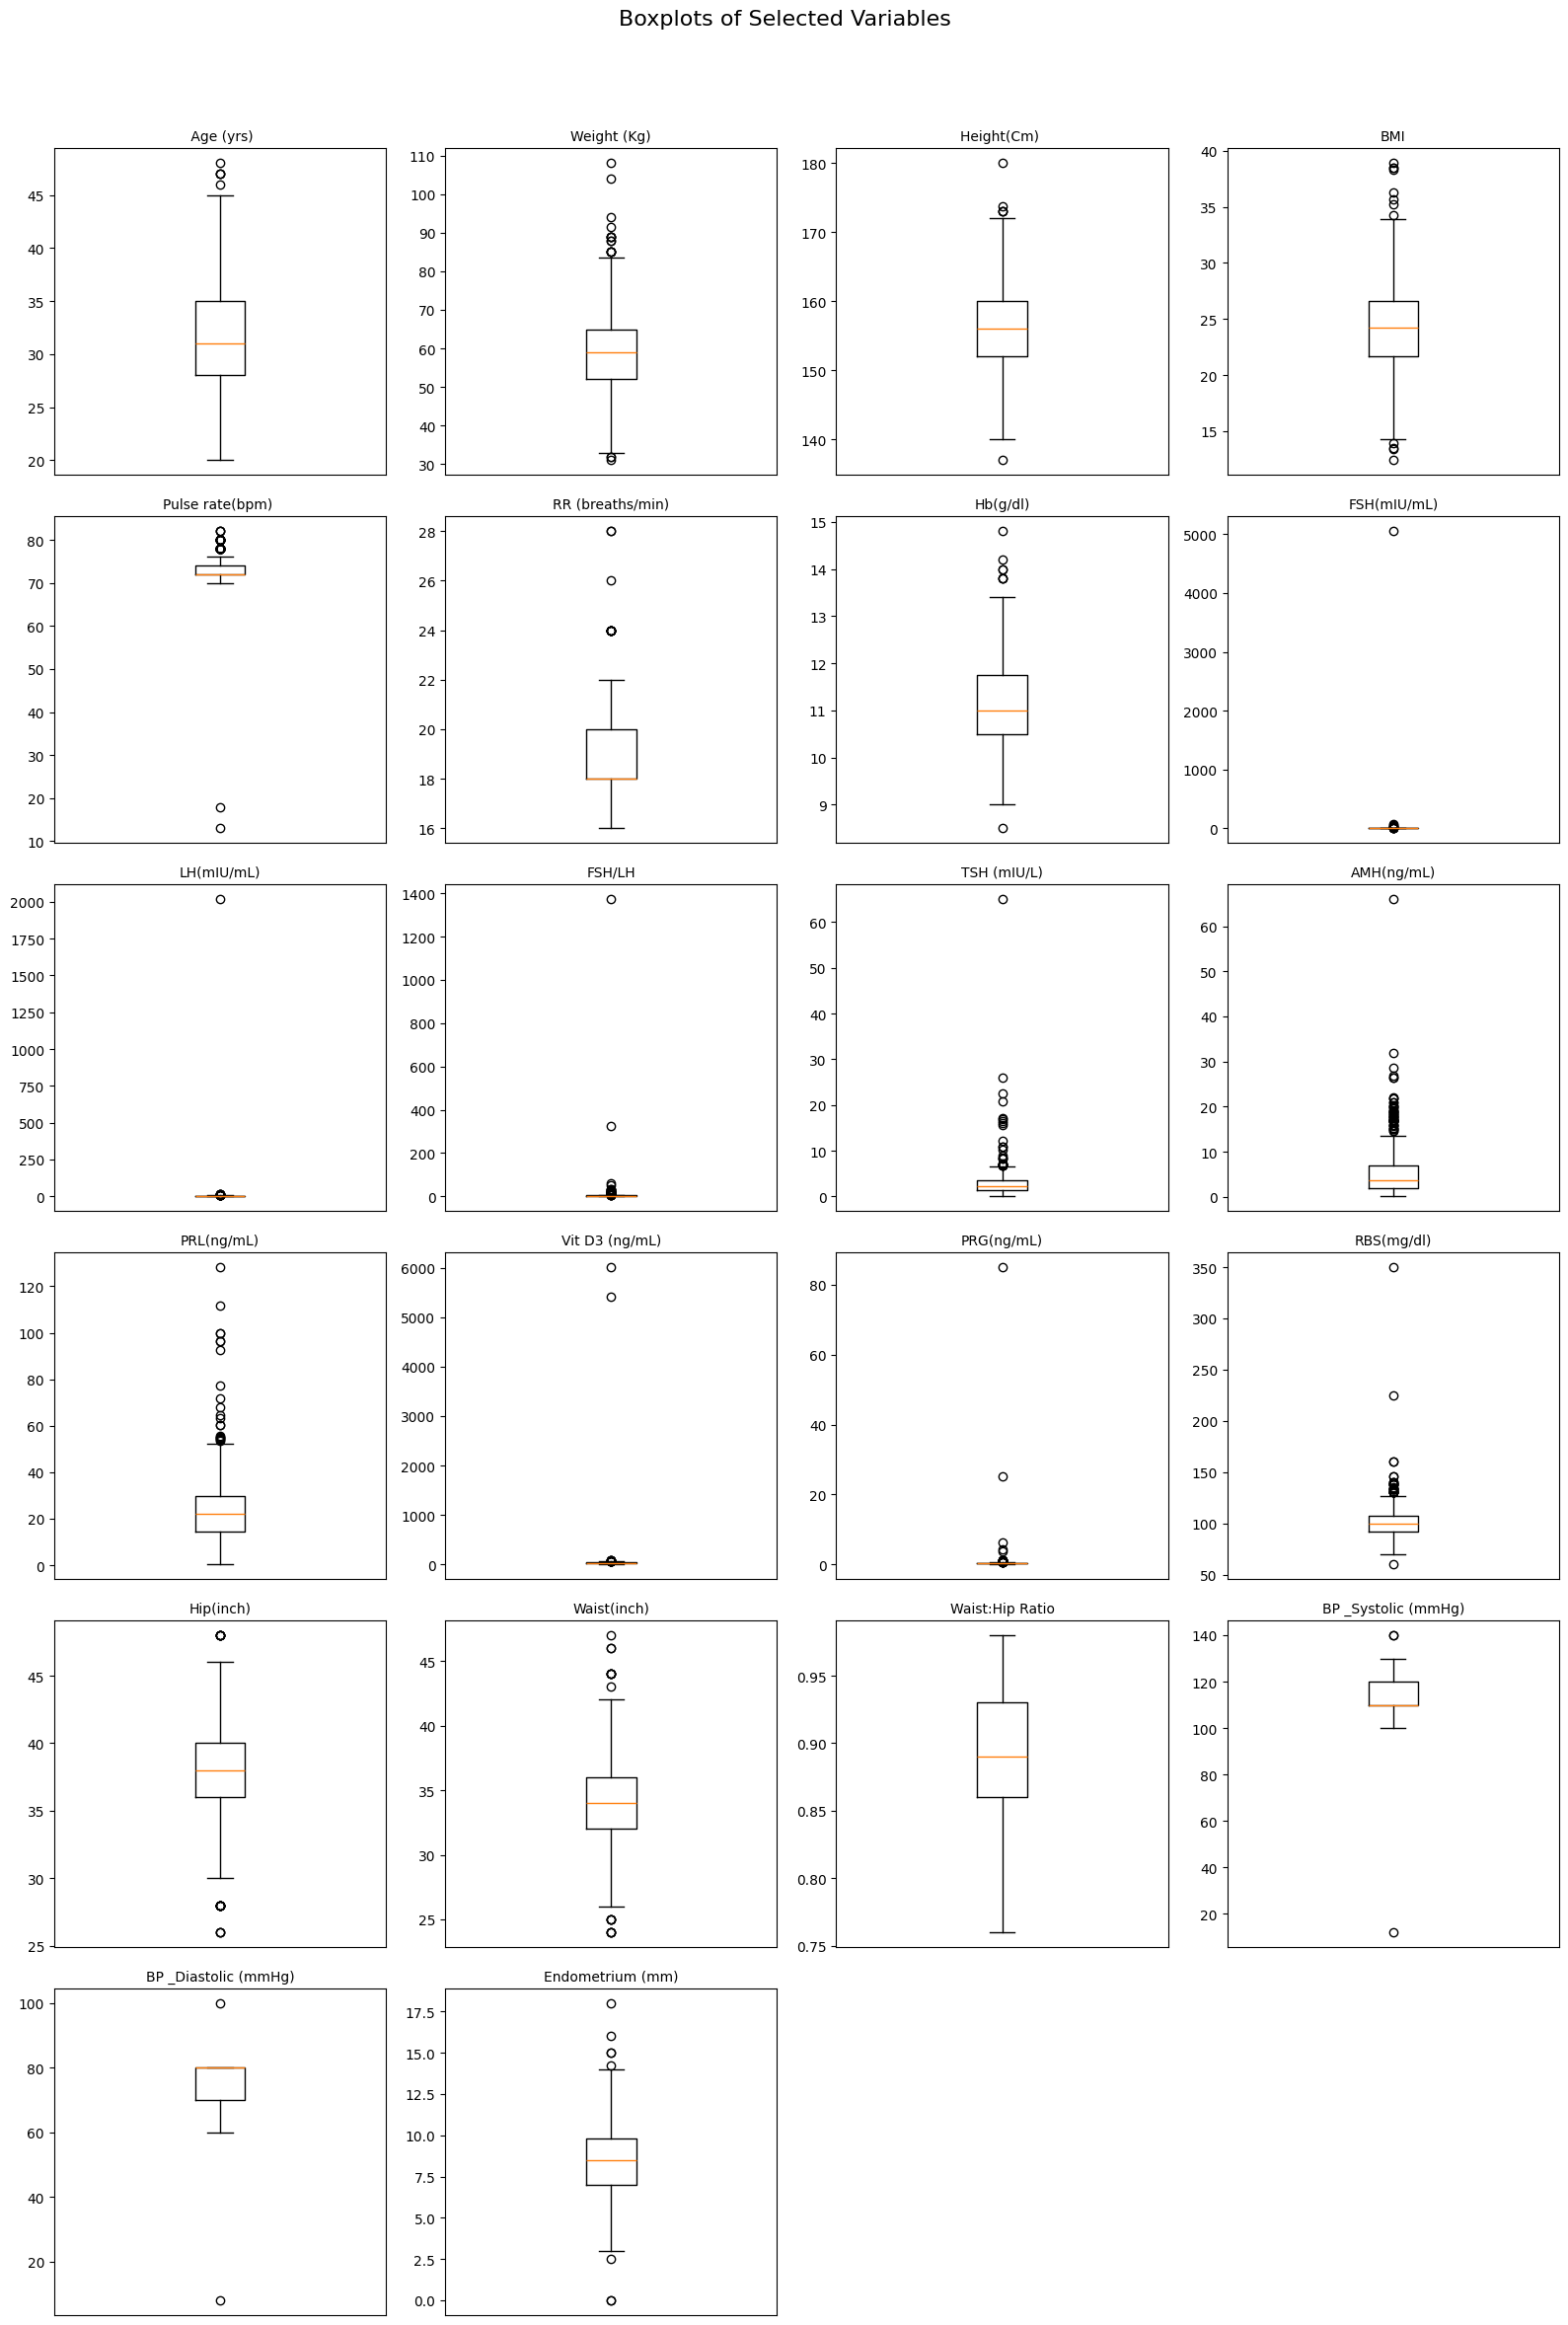

In [138]:
import matplotlib.pyplot as plt
import math

n_cols = 4
n_rows = math.ceil(len(continuous_cols) / n_cols)

plt.figure(figsize=(4 * n_cols, 4 * n_rows))

for i, col in enumerate(continuous_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(col, fontsize=10)
    plt.xticks([])

plt.suptitle("Boxplots of Selected Variables", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## V. Correlation Analysis

In [139]:
# the correlation matrix raised a value error so I had to this conversion
import numpy as np

for col in df.columns:
    if df[col].dtype == 'object':
        # Remove everything except numbers, minus sign, and dot
        df[col] = df[col].str.replace(r'[^0-9.-]', '', regex=True)

        # Fix cases like '1.99.' → '1.99'
        df[col] = df[col].str.rstrip('.')

        # Convert to numeric, force errors to NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['PCOS (Y/N)'].value_counts(dropna=False)
df['PCOS (Y/N)'] = df['PCOS (Y/N)'].astype(float)
corr_matrix = df.corr(method='pearson')
corr_matrix




,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
PCOS (Y/N),1.000000,-0.172436,0.210280,0.066361,0.198800,0.034244,0.092437,0.038031,0.086934,0.402312,...,0.288609,0.381772,0.069481,0.006976,0.035110,0.601445,0.651032,0.129181,0.094268,0.109132
Age (yrs),-0.172436,1.000000,-0.031582,-0.121124,0.019978,-0.012655,0.045910,0.089509,-0.022466,-0.086540,...,-0.032975,-0.036141,-0.022473,0.073719,0.064234,-0.114631,-0.158918,-0.019878,-0.082276,-0.102392
Weight (Kg),0.210280,-0.031582,1.000000,0.420005,0.901731,0.071601,0.019995,0.045048,0.008979,0.201862,...,0.064125,0.163327,-0.065989,0.027661,0.129773,0.172146,0.124867,-0.023849,-0.075312,-0.008622
Height(Cm),0.066361,-0.121124,0.420005,1.000000,-0.006838,0.039981,-0.073801,-0.031093,0.025084,-0.020910,...,0.063415,0.034226,0.013151,-0.069650,0.010791,0.103583,0.076021,-0.028160,0.058097,-0.054325
BMI,0.198800,0.019978,0.901731,-0.006838,1.000000,0.060562,0.050256,0.063867,0.002855,0.235571,...,0.044645,0.159830,-0.078346,0.070578,0.138467,0.142619,0.104741,-0.013727,-0.113067,0.011030
Blood Group,0.034244,-0.012655,0.071601,0.039981,0.060562,1.000000,0.047719,-0.023064,-0.002153,0.123744,...,0.039513,-0.033894,0.066375,0.030656,0.052467,0.059100,0.014495,-0.038032,-0.017647,-0.014156
Pulse rate(bpm),0.092437,0.045910,0.019995,-0.073801,0.050256,0.047719,1.000000,0.305751,-0.052581,0.103183,...,-0.004072,0.059328,-0.038395,-0.024781,0.007275,0.041366,0.049045,-0.048481,-0.034087,-0.040805
RR (breaths/min),0.038031,0.089509,0.045048,-0.031093,0.063867,-0.023064,0.305751,1.000000,-0.038149,0.012243,...,0.033174,0.136502,-0.052550,0.014582,0.056182,0.069396,0.012541,-0.028715,-0.020636,-0.067545
Hb(g/dl),0.086934,-0.022466,0.008979,0.025084,0.002855,-0.002153,-0.052581,-0.038149,1.000000,0.039702,...,0.052195,0.076014,0.013958,0.054375,-0.000962,0.061698,0.072996,0.031502,0.023710,-0.064996
Cycle(R/I),0.402312,-0.086540,0.201862,-0.020910,0.235571,0.123744,0.103183,0.012243,0.039702,1.000000,...,0.128025,0.209833,-0.008522,0.050911,0.083940,0.294146,0.253671,0.033719,0.015122,0.041056


In [140]:
corr_abs = df.corr(numeric_only=True).abs()

upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

redundant_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] >= 0.8
]

redundant_pairs


[('BMI', 'Weight (Kg)', np.float64(0.9017313396378802)),
 ('FSH/LH', 'FSH(mIU/mL)', np.float64(0.9719566019649433)),
 ('Waist(inch)', 'Hip(inch)', np.float64(0.8737004008293406)),
 ('Follicle No. (R)', 'Follicle No. (L)', np.float64(0.8036325655060306))]

In [141]:
pcos_corr = df.corr(numeric_only=True)['PCOS (Y/N)'].drop('PCOS (Y/N)')
irrelevant_vars = pcos_corr[abs(pcos_corr) < 0.05].sort_values()

irrelevant_vars


,PCOS (Y/N)
PRG(ng/mL),-0.043771
FSH(mIU/mL),-0.030300
I beta-HCG(mIU/mL),-0.027820
Pregnant(Y/N),-0.026586
FSH/LH,-0.018533
TSH (mIU/L),-0.009697
PRL(ng/mL),0.003559
BP _Systolic (mmHg),0.006976
Waist:Hip Ratio,0.007936
II beta-HCG(mIU/mL),0.012993


In [142]:
df_reduced = df.drop(columns=irrelevant_vars.index)

df_reduced.shape


(539, 28)

## VI. Feature Selection Based on Correlation (FDS)

In [143]:
pcos_corr = df.corr(numeric_only=True)['PCOS (Y/N)'].drop('PCOS (Y/N)')

relevant_features = pcos_corr[abs(pcos_corr) >= 0.3].sort_values(ascending=False)

relevant_features

selected_cols = relevant_features.index.tolist()
inter_corr = df[selected_cols].corr().abs()

inter_corr
final_features = [
    col for col in selected_cols
    if col not in redundant_pairs

]

inter_corr


,Follicle No. (R),Follicle No. (L),Skin darkening (Y/N),hair growth(Y/N),Weight gain(Y/N),Cycle(R/I),Fast food (Y/N)
Follicle No. (R),1.000000,0.803633,0.321627,0.273101,0.255570,0.253671,0.248331
Follicle No. (L),0.803633,1.000000,0.323157,0.312024,0.257618,0.294146,0.231849
Skin darkening (Y/N),0.321627,0.323157,1.000000,0.376066,0.353170,0.221636,0.337490
hair growth(Y/N),0.273101,0.312024,0.376066,1.000000,0.299858,0.281760,0.296676
Weight gain(Y/N),0.255570,0.257618,0.353170,0.299858,1.000000,0.258999,0.373402
Cycle(R/I),0.253671,0.294146,0.221636,0.281760,0.258999,1.000000,0.209833
Fast food (Y/N),0.248331,0.231849,0.337490,0.296676,0.373402,0.209833,1.000000


During preprocessing, identifier columns such as patient ID and file number were removed since they do not carry analytical value. Missing values were handled selectively: rows with missing values in key categorical variables were dropped to avoid unreliable imputation, while numerical missing values were handled carefully to preserve data integrity. Categorical variables were encoded into numerical form, with binary Yes/No variables mapped to 0 and 1 and blood group encoded using one-hot encoding. Outliers were detected using the IQR method and, given the medical nature of the data, extreme values were treated through capping rather than outright removal. Feature selection was then performed using correlation analysis, retaining variables that showed moderate to strong association with PCOS while removing redundant and weakly correlated features. As a result, the final dataset is fully numerical, non-redundant, and clean, making it well-suited for modeling and further analysis.

## VII. Feature scaling

In [144]:
from sklearn.model_selection import train_test_split

target = "PCOS (Y/N)"

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [145]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.describe().loc[["mean", "std"]]



,Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle(R/I),Cycle length(days),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
mean,-3.379612e-16,-3.544471e-16,7.501089e-16,-1.417788e-15,4.698484e-16,-8.160526e-16,3.297182e-16,-3.486770e-15,-1.246747e-16,2.720175e-16,...,-4.945773e-17,5.151847e-17,3.091108e-17,3.214753e-16,7.830807e-16,8.242955e-18,-2.472887e-17,-1.895880e-16,1.566161e-16,-4.451196e-16
std,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,...,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00,1.001162e+00


## VIII. Training models for the first time

In [146]:
# Data prep
X_train_base = X_train_scaled[final_features]
X_test_base = X_test_scaled[final_features]
models = {}



### Training Logistic regression

In [147]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
baseline_model.fit(X_train_base, y_train)
models["Logistic Regression"] = baseline_model

### Training SVM

In [148]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train_base, y_train)

models["SVM"] = svm_model


### Training random forest

In [149]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train_base, y_train)

models["Random Forest"] = rf_model


### Models' Evaluation

In [150]:
from sklearn.metrics import accuracy_score, f1_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_base)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,F1-score
0,Logistic Regression,0.879630,0.821918
1,SVM,0.851852,0.789474
2,Random Forest,0.870370,0.805556


## IX. Dimensionality reduction

## --> **PCA**: Principle component analysis

In [151]:
X_train_pca_input = X_train_scaled[final_features]
X_test_pca_input = X_test_scaled[final_features]


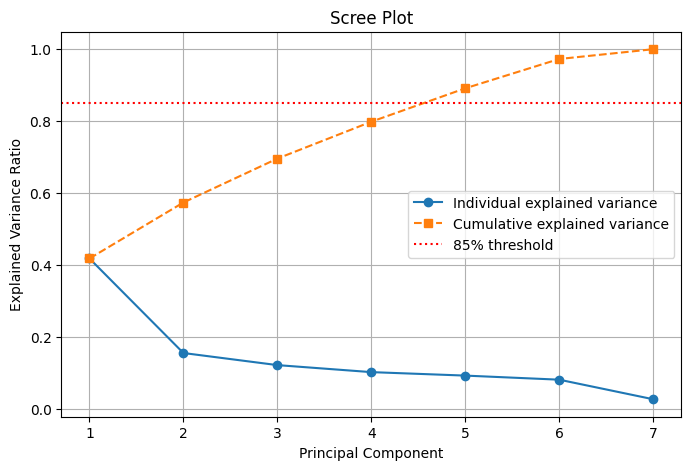

In [153]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker='o',
    label='Individual explained variance'
)

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='s',
    linestyle='--',
    label='Cumulative explained variance'
)

plt.axhline(y=0.85, color='red', linestyle=':', label='85% threshold')

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.legend()
plt.grid(True)
plt.show()


In [152]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

pca = PCA()
pca.fit(X_train_pca_input)


PCA()

In [154]:
n_components_pca = np.argmax(cumulative_variance >= 0.85) + 1
n_components_pca


np.int64(5)

In [155]:
pca_final = PCA(n_components=n_components_pca)

X_train_pca = pca_final.fit_transform(X_train_pca_input)
X_test_pca = pca_final.transform(X_test_pca_input)


In [156]:
X_train_pca = pd.DataFrame(
    X_train_pca,
    index=X_train.index,
    columns=[f"PC{i+1}" for i in range(n_components_pca)]
)

X_test_pca = pd.DataFrame(
    X_test_pca,
    index=X_test.index,
    columns=[f"PC{i+1}" for i in range(n_components_pca)]
)

X_train_pca.head()


,PC1,PC2,PC3,PC4,PC5
448,2.832130,-1.359031,0.949769,0.103700,-0.150583
459,-1.381749,-0.685241,-0.591816,-0.197653,1.163978
114,1.845685,-0.019740,-0.076018,1.650404,-1.833806
514,-0.242648,0.687916,-0.927109,-0.236194,1.207528
469,-0.074254,2.481577,-0.383303,0.172455,-0.207317


## Training models after PCA

In [157]:
models_pca = {}

### Training Logistic Regression

In [158]:
from sklearn.linear_model import LogisticRegression

logreg_pca = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_pca.fit(X_train_pca, y_train)

models_pca["Logistic Regression"] = logreg_pca


### Training SVM

In [159]:
from sklearn.svm import SVC

svm_pca = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_pca.fit(X_train_pca, y_train)

models_pca["SVM"] = svm_pca


### Training Random Forest

In [160]:
from sklearn.ensemble import RandomForestClassifier

rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_pca.fit(X_train_pca, y_train)

models_pca["Random Forest"] = rf_pca


### Models' Evaluation

In [161]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results_pca = []

for name, model in models_pca.items():
    y_pred = model.predict(X_test_pca)

    results_pca.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_pca_df = pd.DataFrame(results_pca)
results_pca_df


,Model,Accuracy,F1-score
0,Logistic Regression,0.879630,0.821918
1,SVM,0.861111,0.800000
2,Random Forest,0.879630,0.821918


## --> **FA**: Factor Analysis

### Bartlet and KMO Test

In [189]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=2810e29d9a9a0a7499498aa754dcf0a13e15ecf0b0df6b315d9907ec5b5c8cc9
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [191]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Suitability tests for FA
kmo_all, kmo_model = calculate_kmo(X_train_fa_input)
chi_square_value, p_value = calculate_bartlett_sphericity(X_train_fa_input)

print("KMO:", kmo_model)
print("Bartlett p-value:", p_value)




KMO: 0.736464022144948
Bartlett p-value: 1.8394366072942186e-165


In [162]:
import numpy as np

X_train_fa_input = X_train_scaled[final_features]

# Covariance matrix
cov_matrix = np.cov(X_train_fa_input.T)

# Eigenvalues
eigenvalues, _ = np.linalg.eig(cov_matrix)
eigenvalues = np.real(eigenvalues)

eigenvalues


array([2.93526615, 0.19067491, 1.09181756, 0.85604827, 0.57185405,
       0.71914666, 0.65147147])

In [163]:
n_factors = np.sum(eigenvalues > 1)
n_factors


np.int64(2)

In [164]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(
    n_components=n_factors,
    random_state=42
)

X_train_fa = fa.fit_transform(X_train_fa_input)
X_test_fa = fa.transform(X_test_scaled[final_features])


In [165]:
import pandas as pd

X_train_fa = pd.DataFrame(
    X_train_fa,
    index=X_train.index,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

X_test_fa = pd.DataFrame(
    X_test_fa,
    index=X_test.index,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

X_train_fa.head()


,Factor1,Factor2
448,0.795587,1.483538
459,-0.825065,-0.012189
114,1.093905,0.463967
514,0.314303,-0.681115
469,1.027313,-1.621959


In [166]:
fa_loadings = pd.DataFrame(
    fa.components_.T,
    index=final_features,
    columns=[f"Factor{i+1}" for i in range(n_factors)]
)

fa_loadings


,Factor1,Factor2
Follicle No. (R),0.871594,-0.114663
Follicle No. (L),0.908108,-0.126102
Skin darkening (Y/N),0.424320,0.515987
hair growth(Y/N),0.404072,0.376607
Weight gain(Y/N),0.383004,0.440019
Cycle(R/I),0.331492,0.236578
Fast food (Y/N),0.332667,0.414050


## Training models after FA

In [167]:
models_fa = {}

### Training Logistic Regression

In [168]:
from sklearn.linear_model import LogisticRegression

logreg_fa = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_fa.fit(X_train_fa, y_train)

models_fa["Logistic Regression"] = logreg_fa


### Training SVM

In [169]:
from sklearn.svm import SVC

svm_fa = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_fa.fit(X_train_fa, y_train)

models_fa["SVM"] = svm_fa

### Training Random Forest

In [170]:
from sklearn.ensemble import RandomForestClassifier

rf_fa = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_fa.fit(X_train_fa, y_train)

models_fa["Random Forest"] = rf_fa


### Models' Evaluation

In [171]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results_fa = []

for name, model in models_fa.items():
    y_pred = model.predict(X_test_fa)

    results_fa.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_fa_df = pd.DataFrame(results_fa)
results_fa_df


,Model,Accuracy,F1-score
0,Logistic Regression,0.861111,0.794521
1,SVM,0.870370,0.805556
2,Random Forest,0.870370,0.794118


## X. Cross-validation & Model Selection

In [172]:
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

def cross_validate_all(models, X, y, representation_name, k=5, scoring="f1"):
    results = []

    for model_name, model in models.items():
        scores = cross_val_score(
            model,
            X,
            y,
            cv=k,
            scoring=scoring
        )

        results.append({
            "Representation": representation_name,
            "Model": model_name,
            "Mean F1-score": np.mean(scores),
            "Std F1-score": np.std(scores)
        })

    return pd.DataFrame(results)


### Testing the original models

In [173]:
cv_original = cross_validate_all(
    models,
    X_train_base,
    y_train,
    "Original"
)


### Testing the models after PCA

In [174]:
cv_pca = cross_validate_all(
    models_pca,
    X_train_pca,
    y_train,
    "PCA"
)

### Testing the models after FA

In [175]:
cv_fa = cross_validate_all(
    models_fa,
    X_train_fa,
    y_train,
    "FA"
)

### Final Evalution

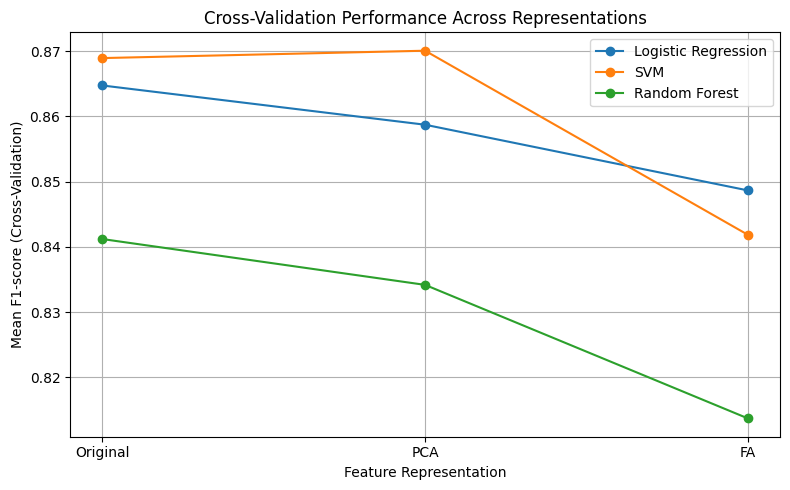

In [176]:
import matplotlib.pyplot as plt
cv_results = pd.concat([cv_original, cv_pca, cv_fa])
cv_results


rep_order = ["Original", "PCA", "FA"]

plt.figure(figsize=(8, 5))

for model in cv_results["Model"].unique():
    subset = cv_results[cv_results["Model"] == model]
    subset = subset.set_index("Representation").loc[rep_order]

    plt.plot(
        rep_order,
        subset["Mean F1-score"],
        marker="o",
        label=model
    )

plt.xlabel("Feature Representation")
plt.ylabel("Mean F1-score (Cross-Validation)")
plt.title("Cross-Validation Performance Across Representations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(8, 5))

# for model in cv_results["Model"].unique():
#     subset = cv_results[cv_results["Model"] == model]
#     subset = subset.set_index("Representation").loc[rep_order]

#     plt.errorbar(
#         rep_order,
#         subset["Mean F1-score"],
#         yerr=subset["Std F1-score"],
#         marker="o",
#         capsize=4,
#         label=model
#     )

# plt.xlabel("Feature Representation")
# plt.ylabel("Mean F1-score (± Std)")
# plt.title("Cross-Validation Performance and Stability")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()




## XI. Clustering Analysis

### --> K-Means algorithm

### Clustering on the PCA Space

In [177]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)
    inertia.append(kmeans.inertia_)

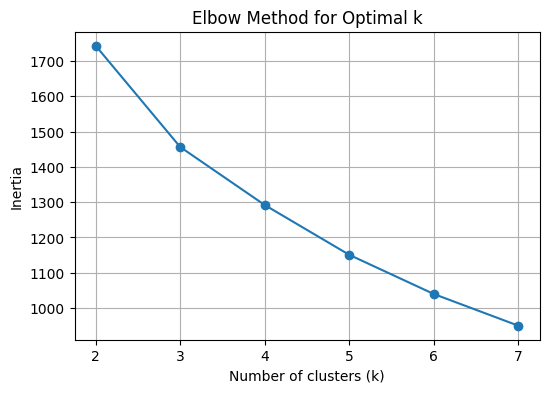

In [178]:
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()


In [179]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train_pca)
    silhouette_scores.append(silhouette_score(X_train_pca, labels))


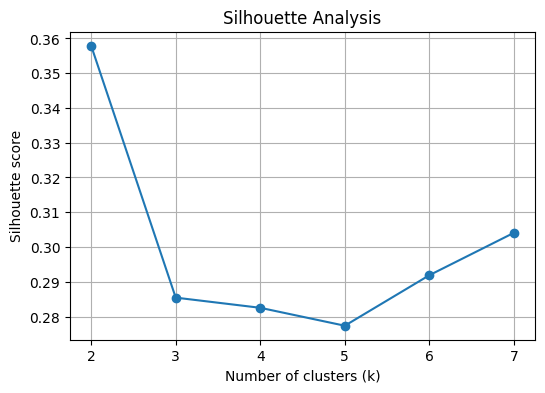

In [180]:
plt.figure(figsize=(6, 4))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.show()


In [181]:
k = 2
kmeans_final = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_train_pca)

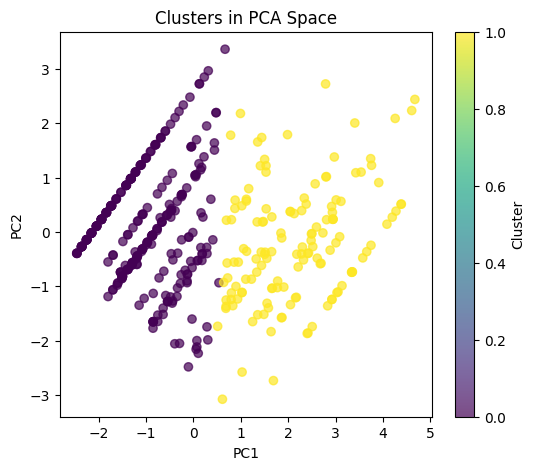

In [182]:
plt.figure(figsize=(6, 5))
plt.scatter(
    X_train_pca.iloc[:, 0],
    X_train_pca.iloc[:, 1],
    c=cluster_labels,
    cmap="viridis",
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters in PCA Space")
plt.colorbar(label="Cluster")
plt.show()


In [183]:
df_pca_clusters = df.loc[X_train.index].copy()
df_pca_clusters["Cluster"] = cluster_labels
df_pca_clusters.groupby("Cluster")[final_features].mean()


,Follicle No. (R),Follicle No. (L),Skin darkening (Y/N),hair growth(Y/N),Weight gain(Y/N),Cycle(R/I),Fast food (Y/N)
Cluster,,,,,,,
0,4.770548,4.356164,0.085616,0.089041,0.178082,2.294521,0.345890
1,10.107914,9.647482,0.741007,0.640288,0.748201,3.086331,0.884892


### Clustering on FA Space

In [184]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range = range(2, 7)
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_train_fa)
    sil_scores.append(silhouette_score(X_train_fa, labels))


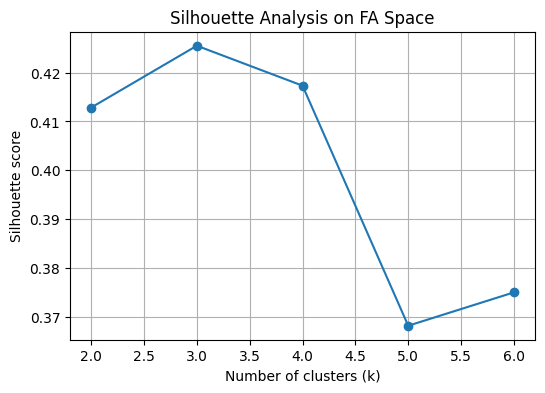

In [185]:
plt.figure(figsize=(6, 4))
plt.plot(K_range, sil_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Analysis on FA Space")
plt.grid(True)
plt.show()

In [186]:
k = 2
kmeans_fa = KMeans(n_clusters=k, random_state=42)
cluster_labels_fa = kmeans_fa.fit_predict(X_train_fa)

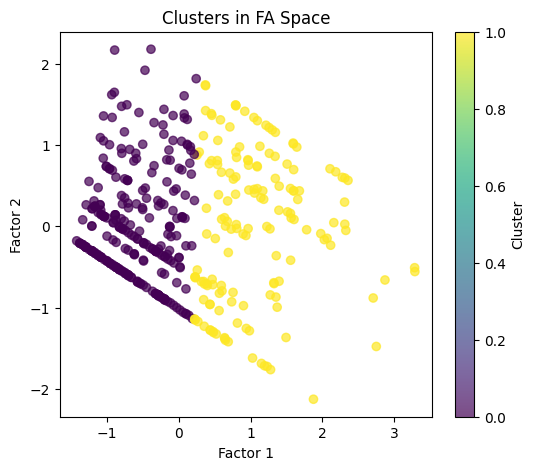

In [187]:
plt.figure(figsize=(6, 5))
plt.scatter(
    X_train_fa.iloc[:, 0],
    X_train_fa.iloc[:, 1],
    c=cluster_labels_fa,
    cmap="viridis",
    alpha=0.7
)
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")
plt.title("Clusters in FA Space")
plt.colorbar(label="Cluster")
plt.show()

In [188]:
df_fa_clusters = df.loc[X_train.index].copy()
df_fa_clusters["Cluster"] = cluster_labels_fa
df_fa_clusters.groupby("Cluster")[final_features].mean()


,Follicle No. (R),Follicle No. (L),Skin darkening (Y/N),hair growth(Y/N),Weight gain(Y/N),Cycle(R/I),Fast food (Y/N)
Cluster,,,,,,,
0,3.938406,3.594203,0.173913,0.144928,0.246377,2.362319,0.416667
1,11.038710,10.458065,0.516129,0.483871,0.567742,2.883871,0.703226
